# Conociendo el dataset

Lo que trata: identifica si una red hay una amenaza en base a su uso

In [40]:

# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from random import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
# Cargar dataset
df = pd.read_csv("data/networkanomalydataset.csv")
# Mostrar primeras filas
df.head(5)

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0


In [42]:
df.isnull().sum()

Inbound Rate(bit/s)                  0
Outbound Rate(bit/s)                 0
Inbound Bandwidth Utilization(%)     0
Outbound Bandwidth Utilization(%)    0
Label                                0
dtype: int64

### No hay datos faltantes

Aqui se esta aplicando EDA
mas info en: https://medium.com/@amaanuddinparvez/network-anomaly-detection-using-machine-learning-a-complete-guide-39165c04e373

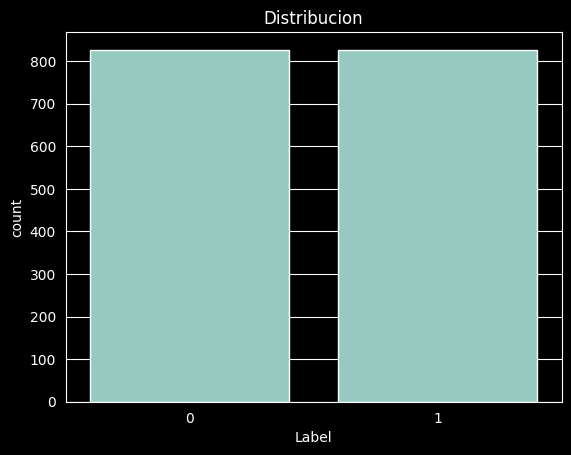

In [43]:
sns.countplot(x="Label", data=df)
plt.title('Distribucion')
plt.show()

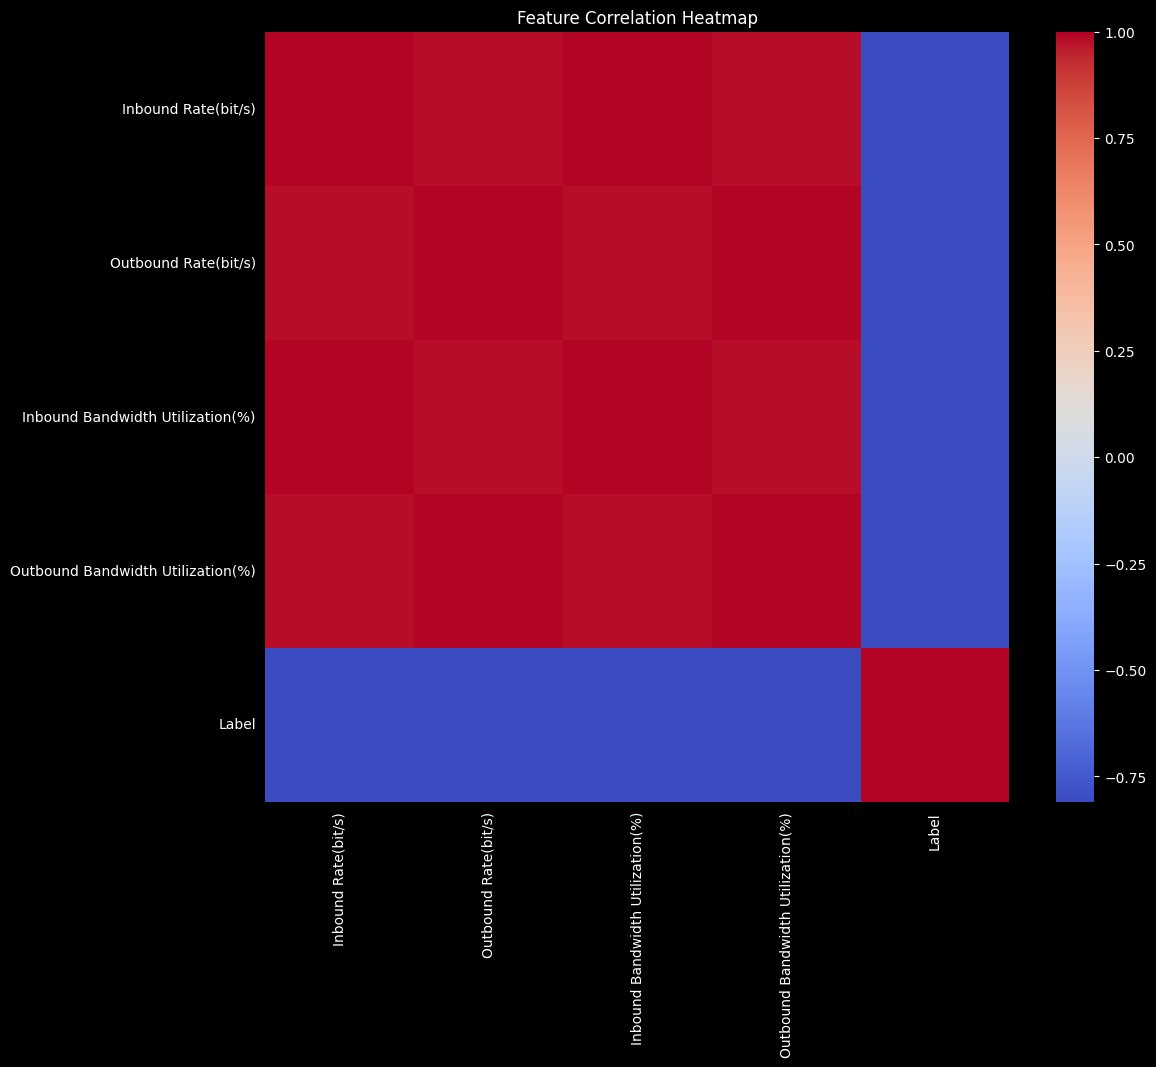

In [44]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


In [45]:
np.random.seed(42)

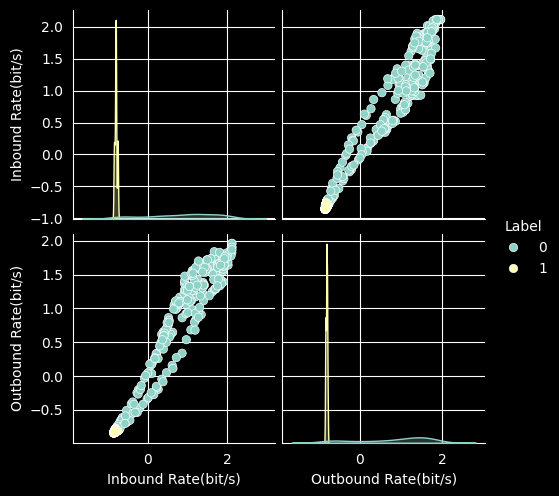

In [46]:
# Pairplot for selected features
sampled_df = df.sample(500)
sns.pairplot(sampled_df[['Inbound Rate(bit/s)',
                         'Outbound Rate(bit/s)',
                         'Label']], hue='Label')
plt.show()



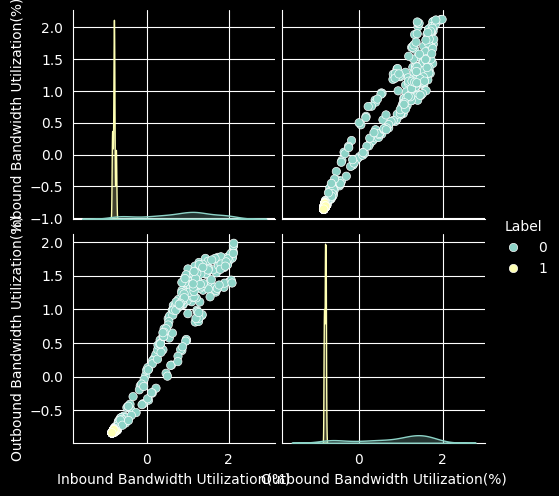

In [47]:
# Pairplot for selected features
sampled_df = df.sample(500)
sns.pairplot(sampled_df[['Inbound Bandwidth Utilization(%)',
                         'Outbound Bandwidth Utilization(%)',
                         'Label']], hue='Label')
plt.show()


## Deteccion de outliner

## TODO:
    * Investigar las diferentes tecncias de identificacion de datos anomalos
    * Desarrollarlo
    * Argumentarlo
    * decidir si eliminarlo

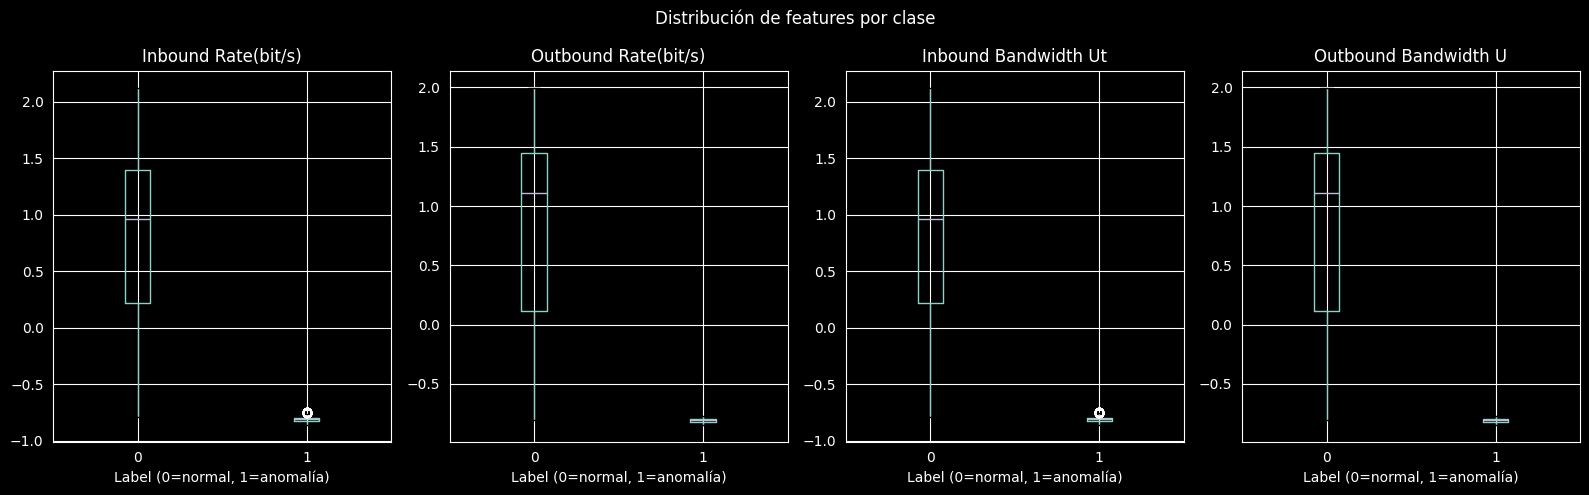

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, X.columns):
    df.boxplot(column=col, by='Label', ax=ax)
    ax.set_title(col[:20])
    ax.set_xlabel('Label (0=normal, 1=anomalía)')
plt.suptitle('Distribución de features por clase')
plt.tight_layout()
plt.show()

# Separacion de datos

### Opcional:
Escalar los datos

#### TODO revisar si cambiar el modelo de clasificacion del clf

In [50]:
X = df.drop('Label', axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       247
           1       1.00      1.00      1.00       250

    accuracy                           1.00       497
   macro avg       1.00      1.00      1.00       497
weighted avg       1.00      1.00      1.00       497

[[246   1]
 [  0 250]]
